In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/cleaned_healthcare_dataset.csv')

### Dataset Overview

Let's display the first 5 rows of the dataset to get a glimpse of its structure and content. We will also check the column information to understand data types and identify any missing values.

In [2]:
# Display the first 5 rows of the DataFrame
display(df.head())

# Display information about the DataFrame, including data types and non-null values
df.info()

,patient_id,first_name,last_name,age,gender,blood_type,admission_date,discharge_date,diagnosis,diagnosis_code,...,lab_test_2,lab_test_2_result,lab_test_3,lab_test_3_result,treatment_type,length_of_stay,readmission_30_days,outcome,insurance_type,charges
0,P001,John,Smith,45,Male,O+,2026-01-15,2026-01-22,Hypertension,I10,...,Glucose,125,Cholesterol,220,Medication,7,No,Improved,Private,8500
1,P002,Mary,Johnson,62,Female,A+,2026-01-18,2026-01-25,Diabetes Type 2,E11,...,Blood Pressure,135/85,HbA1c,7.8,Medication,7,No,Improved,Medicare,9200
2,P003,Robert,Williams,38,Male,B+,2026-01-20,2026-01-23,Pneumonia,J18.9,...,Blood Culture,Negative,White Blood Count,12000,Antibiotics,3,No,Recovered,Private,6500
3,P004,Linda,Brown,55,Female,AB+,2026-01-22,2026-02-05,Coronary Artery Disease,I25.10,...,Cholesterol,250,Troponin,0.15,Cardiac Procedure,14,Yes,Stable,Private,25000
4,P005,Michael,Davis,29,Male,O-,2026-01-25,2026-01-27,Appendicitis,K35.80,...,White Blood Count,15000,CRP,45,Surgery,2,No,Recovered,Private,12000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           30 non-null     object
 1   first_name           30 non-null     object
 2   last_name            30 non-null     object
 3   age                  30 non-null     int64 
 4   gender               30 non-null     object
 5   blood_type           30 non-null     object
 6   admission_date       30 non-null     object
 7   discharge_date       30 non-null     object
 8   diagnosis            30 non-null     object
 9   diagnosis_code       30 non-null     object
 10  primary_condition    30 non-null     object
 11  comorbidities        30 non-null     object
 12  medication_1         30 non-null     object
 13  medication_2         30 non-null     object
 14  medication_3         30 non-null     object
 15  lab_test_1           30 non-null     object
 16  lab_test_1

### Data Preprocessing

First, let's convert the `admission_date` and `discharge_date` columns to datetime objects. Then, we will identify and one-hot encode all categorical features, excluding identifier columns and the target variable (`readmission_30_days`).

In [3]:
# Convert date columns to datetime objects
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude identifier columns and the target variable from encoding
columns_to_exclude = ['patient_id', 'first_name', 'last_name', 'diagnosis_code', 'readmission_30_days']
categorical_cols = [col for col in categorical_cols if col not in columns_to_exclude]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert the target variable 'readmission_30_days' to numerical (0 or 1)
df_encoded['readmission_30_days'] = df_encoded['readmission_30_days'].map({'Yes': 1, 'No': 0})

# Display the first few rows of the preprocessed DataFrame and its info
display(df_encoded.head())
df_encoded.info()

,patient_id,first_name,last_name,age,admission_date,discharge_date,diagnosis_code,length_of_stay,readmission_30_days,charges,...,treatment_type_Physical Therapy,treatment_type_Radiation,treatment_type_Rehabilitation,treatment_type_Supportive Care,treatment_type_Surgery,treatment_type_Therapy,outcome_Recovered,outcome_Stable,insurance_type_Medicare,insurance_type_Private
0,P001,John,Smith,45,2026-01-15,2026-01-22,I10,7,0,8500,...,False,False,False,False,False,False,False,False,False,True
1,P002,Mary,Johnson,62,2026-01-18,2026-01-25,E11,7,0,9200,...,False,False,False,False,False,False,False,False,True,False
2,P003,Robert,Williams,38,2026-01-20,2026-01-23,J18.9,3,0,6500,...,False,False,False,False,False,False,True,False,False,True
3,P004,Linda,Brown,55,2026-01-22,2026-02-05,I25.10,14,1,25000,...,False,False,False,False,False,False,False,True,False,True
4,P005,Michael,Davis,29,2026-01-25,2026-01-27,K35.80,2,0,12000,...,False,False,False,False,True,False,True,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Columns: 225 entries, patient_id to insurance_type_Private
dtypes: bool(215), datetime64[ns](2), int64(4), object(4)
memory usage: 8.8+ KB


### Model Training and Evaluation

First, let's define our features (X) and target variable (y). The target variable will be `readmission_30_days`.

Then, we'll split the data into training and testing sets to build and evaluate a predictive model. We will use a `LogisticRegression` model, which is suitable for binary classification tasks like predicting readmission.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y)
X = df_encoded.drop(columns=['patient_id', 'first_name', 'last_name', 'admission_date', 'discharge_date', 'readmission_30_days', 'diagnosis_code'])
y = df_encoded['readmission_30_days']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train a Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)

Model Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.00      0.00      0.00         1

    accuracy                           0.78         9
   macro avg       0.44      0.44      0.44         9
weighted avg       0.78      0.78      0.78         9


Confusion Matrix:
 [[7 1]
 [1 0]]


In [6]:
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(predictions_df)

,Actual,Predicted
22,0,0
21,0,0
7,0,0
12,0,0
29,0,0
16,0,0
3,1,0
20,0,1
8,0,0


### Prediction Charts: Confusion Matrix

Let's visualize the confusion matrix to better understand the model's performance in classifying readmission outcomes.

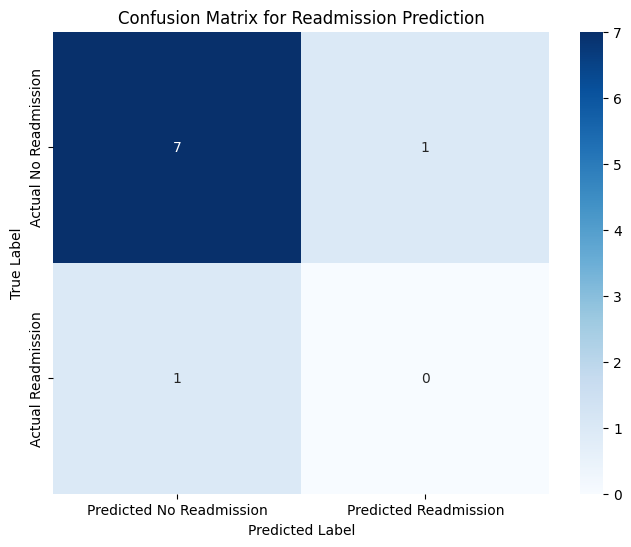

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Readmission', 'Predicted Readmission'],
            yticklabels=['Actual No Readmission', 'Actual Readmission'])
plt.title('Confusion Matrix for Readmission Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()